In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 

In [7]:
# News categorization using TF-IDF and Naive Bayes.

df = pd.read_csv("bbc_news_dataset.csv")
print(df.head())
print(df.info())

   ArticleId                                               Text  Category
0       1833  worldcom ex-boss launches defence lawyers defe...  business
1        154  german business confidence slides german busin...  business
2       1101  bbc poll indicates economic gloom citizens in ...  business
3       1976  lifestyle  governs mobile choice  faster  bett...      tech
4        917  enron bosses in $168m payout eighteen former e...  business
<class 'pandas.DataFrame'>
RangeIndex: 1490 entries, 0 to 1489
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   ArticleId  1490 non-null   int64
 1   Text       1490 non-null   str  
 2   Category   1490 non-null   str  
dtypes: int64(1), str(2)
memory usage: 35.1 KB
None


In [8]:
X = df['Text']
y = df['Category']

In [12]:
category_names = y.unique()
category_names

<StringArray>
['business', 'tech', 'politics', 'sport', 'entertainment']
Length: 5, dtype: str

In [14]:
value_counts = df['Category'].value_counts()
value_counts

Category
sport            346
business         336
politics         274
entertainment    273
tech             261
Name: count, dtype: int64

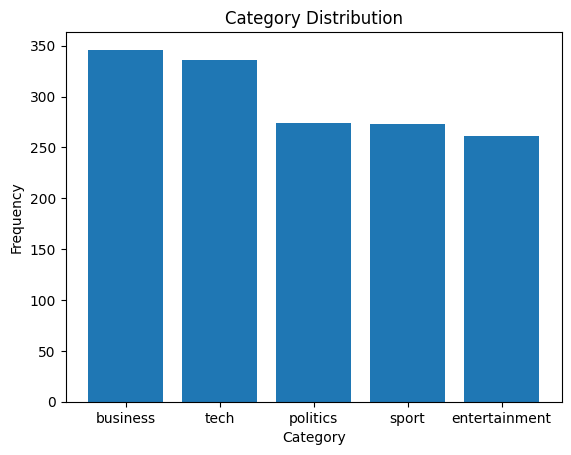

In [20]:
plt.bar(x=category_names, height=value_counts)
plt.title("Category Distribution")
plt.xlabel("Category")
plt.ylabel("Frequency")
plt.show()

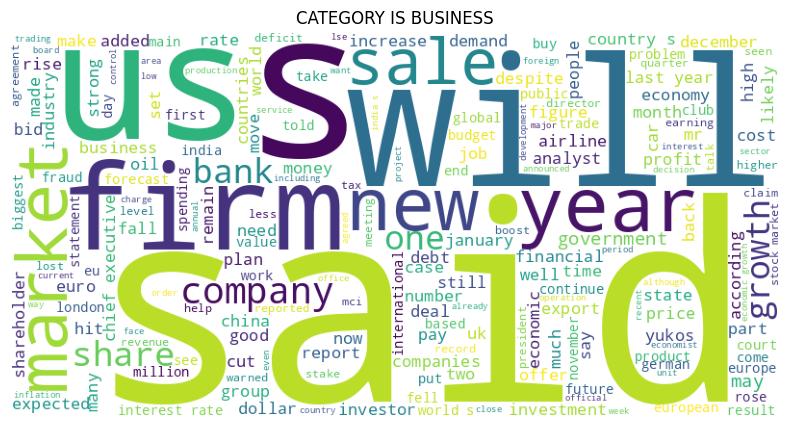

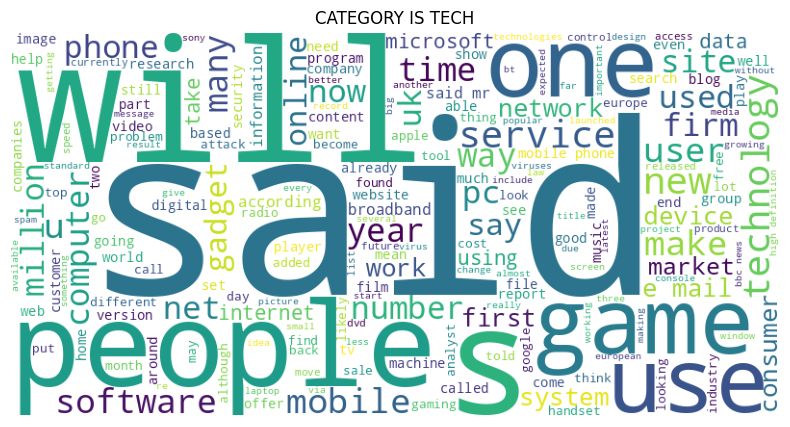

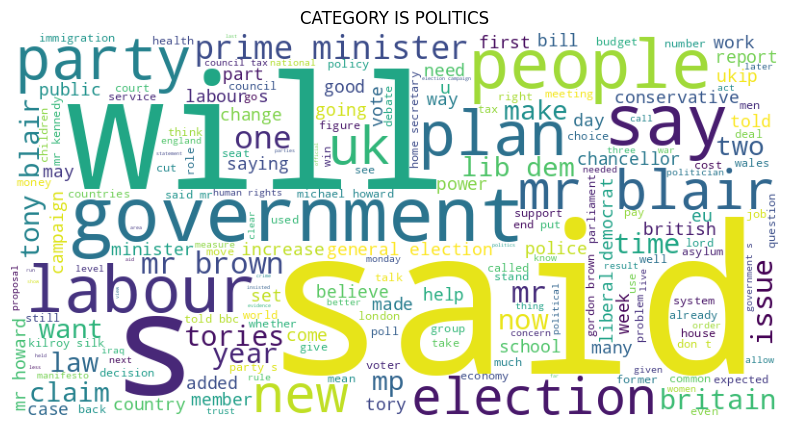

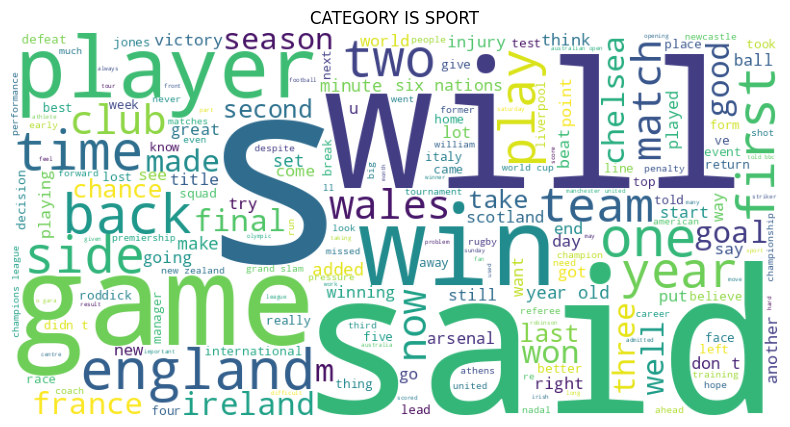

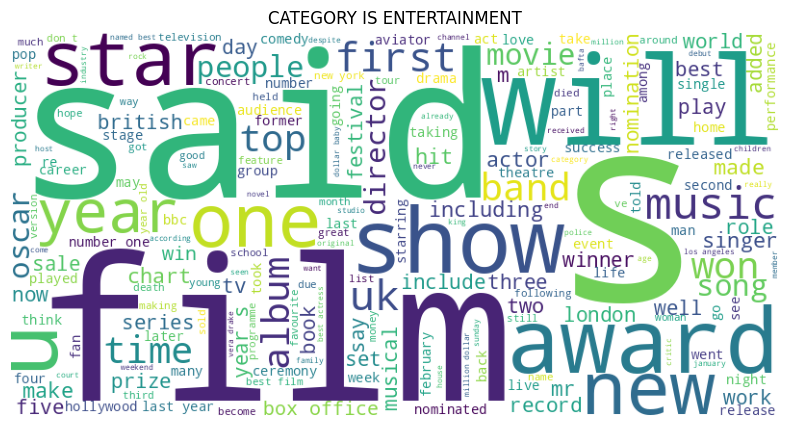

In [31]:
from wordcloud import WordCloud

for category in category_names:
    text = " ".join(
        df[df["Category"] == category]["Text"].values
    )  # harek text lai jodeko
    wc = WordCloud(width=800, height=400, background_color="white").generate(text)

    plt.figure(figsize=(10, 5))
    plt.title(f"CATEGORY IS {str.upper(category)}")
    plt.imshow(wc)
    plt.axis("off")
    plt.show()

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

model = make_pipeline(TfidfVectorizer(stop_words="english"), MultinomialNB())

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [ ]:
model.predict(
    [
        "Amazing Movie",
        "worst film ever",
        "bad video",
        "chelsea is the most famous club",
        "amazing movie about chelsea",
        "amazing chelsea movie",
        "nice video of chelsea movie",
        "good movie about tech",
    ]
)

array(['entertainment', 'entertainment', 'tech', 'sport', 'sport',
       'sport', 'sport', 'entertainment'], dtype='<U13')

In [58]:
# classification report.

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

               precision    recall  f1-score   support

     business       0.94      0.97      0.95        75
entertainment       1.00      0.96      0.98        46
     politics       0.91      0.95      0.93        56
        sport       0.97      1.00      0.98        63
         tech       0.98      0.90      0.94        58

     accuracy                           0.96       298
    macro avg       0.96      0.95      0.96       298
 weighted avg       0.96      0.96      0.96       298



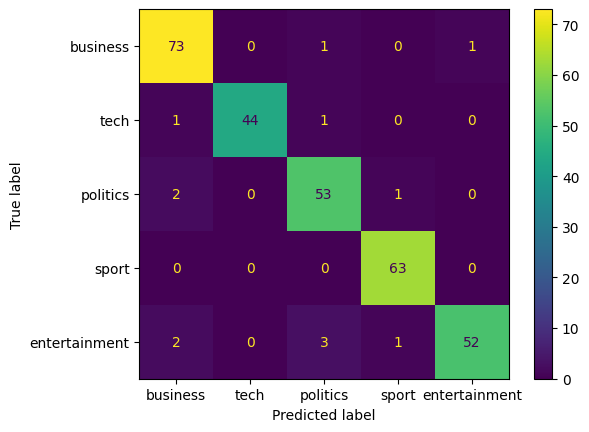

In [61]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test , y_pred)
ConfusionMatrixDisplay(cm , display_labels=category_names).plot()

In [64]:
# testing if our model is actually verifying the category or not.

dataset = [
    "The smartphone manufacturer announced a new processor that doubles battery efficiency using AI cores.",
    "The prime minister faced intense questioning today during a heated debate over the new corporate tax brackets.",
    "After a dramatic three-overtime thriller, the underdogs secured their spot in the championship finals.",
    "Shares of the retail giant tumbled 6% after their quarterly earnings report missed wall street expectations.",
    "The director's highly anticipated sci-fi sequel shattered box office records on its opening weekend.",
    "A major cybersecurity breach has forced the app to reset passwords for millions of global users.",
    "The local council voted unanimously to approve the new zoning laws for downtown commercial properties.",
    "Rumors are swirling that the pop star is planning a surprise stadium tour starting later this winter.",
    "The star quarterback signed a historic four-year contract extension worth a record-breaking sum.",
    "Startups in the green energy sector saw an unprecedented influx of venture capital funding this quarter.",
]


model.predict(dataset)

array(['tech', 'politics', 'sport', 'business', 'entertainment',
       'business', 'politics', 'sport', 'sport', 'business'], dtype='<U13')

In [65]:
# saving the model

import joblib 
joblib.dump(model , "model.joblib")
print(f"Success of model dump")

Success of model dump
